In [1]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
iris_df = pd.read_csv(data_url + 'iris.csv')
iris_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [3]:
iris_df.info()
#데이터 프레임의 기본 정보 확인

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [11]:
iris_df['petal.length'].mean()

np.float64(3.7580000000000005)

In [12]:
iris_df['sepal.width'].median()

np.float64(3.0)

In [17]:
iris_df['petal.width'].mode()[0]

np.float64(0.2)

In [19]:
sl=iris_df['sepal.length']

Q1=sl.quantile(0.25)
Q3=sl.quantile(0.75)
IQR=Q3-Q1
print(f"제 1사분위 : {Q1} \n 제 3사분위 : {Q3} \n IQR : {IQR}")

제 1사분위 : 5.1 
 제 3사분위 : 6.4 
 IQR : 1.3000000000000007


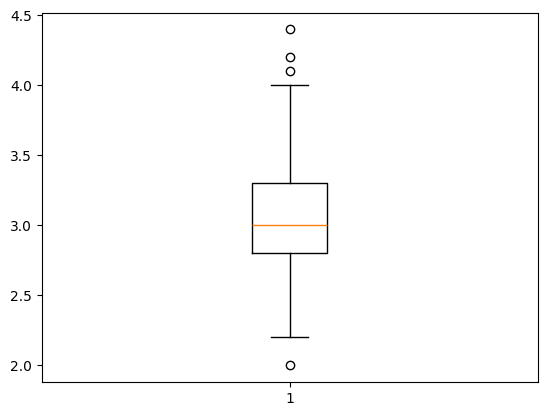

In [22]:
plt.boxplot(iris_df['sepal.width'])
plt.show()

<Axes: >

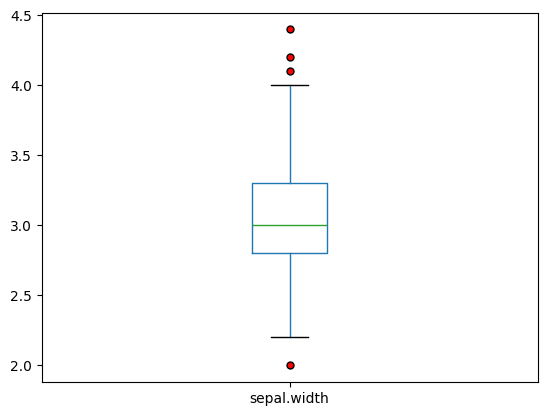

In [25]:
iris_df.boxplot(
    column=['sepal.width'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)

In [27]:
print(f"범위 : {iris_df['petal.width'].max()-iris_df['petal.width'].min()}")
print(f"표준편차 : {iris_df['petal.width'].std(ddof=0)}")
print(f"분산 : {iris_df['petal.width'].var(ddof=0)}")

범위 : 2.4
표준편차 : 0.7596926279021594
분산 : 0.5771328888888888


In [30]:
pl = iris_df['petal.length']
iris_df['petal_length_scaled'] = (pl - pl.min()) / (pl.max() - pl.min())
iris_df[['petal.length', 'petal_length_scaled']].head()

,petal.length,petal_length_scaled
0,1.4,0.067797
1,1.4,0.067797
2,1.3,0.050847
3,1.5,0.084746
4,1.4,0.067797


In [31]:
iris_df

,sepal.length,sepal.width,petal.length,petal.width,variety,petal_length_scaled
0,5.1,3.5,1.4,0.2,Setosa,0.067797
1,4.9,3.0,1.4,0.2,Setosa,0.067797
2,4.7,3.2,1.3,0.2,Setosa,0.050847
3,4.6,3.1,1.5,0.2,Setosa,0.084746
4,5.0,3.6,1.4,0.2,Setosa,0.067797
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica,0.711864
146,6.3,2.5,5.0,1.9,Virginica,0.677966
147,6.5,3.0,5.2,2.0,Virginica,0.711864
148,6.2,3.4,5.4,2.3,Virginica,0.745763


In [34]:
sw=iris_df['sepal.width']
zscore=(sw-sw.mean())/sw.std(ddof=0)
iris_df['swpal_width_z']=zscore
iris_df

,sepal.length,sepal.width,petal.length,petal.width,variety,petal_length_scaled,swpal_width_z
0,5.1,3.5,1.4,0.2,Setosa,0.067797,1.019004
1,4.9,3.0,1.4,0.2,Setosa,0.067797,-0.131979
2,4.7,3.2,1.3,0.2,Setosa,0.050847,0.328414
3,4.6,3.1,1.5,0.2,Setosa,0.084746,0.098217
4,5.0,3.6,1.4,0.2,Setosa,0.067797,1.249201
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica,0.711864,-0.131979
146,6.3,2.5,5.0,1.9,Virginica,0.677966,-1.282963
147,6.5,3.0,5.2,2.0,Virginica,0.711864,-0.131979
148,6.2,3.4,5.4,2.3,Virginica,0.745763,0.788808


In [36]:
Q1=sw.quantile(0.25)
Q3=sw.quantile(0.75)
IQR=Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

IQR_outlier=iris_df[(sw<lower)|(sw>upper)]
print(f"outliers >> {len(IQR_outlier)}")
IQR_outlier

outliers >> 4


,sepal.length,sepal.width,petal.length,petal.width,variety,petal_length_scaled,swpal_width_z
15,5.7,4.4,1.5,0.4,Setosa,0.084746,3.090775
32,5.2,4.1,1.5,0.1,Setosa,0.084746,2.400185
33,5.5,4.2,1.4,0.2,Setosa,0.067797,2.630382
60,5.0,2.0,3.5,1.0,Versicolor,0.423729,-2.433947


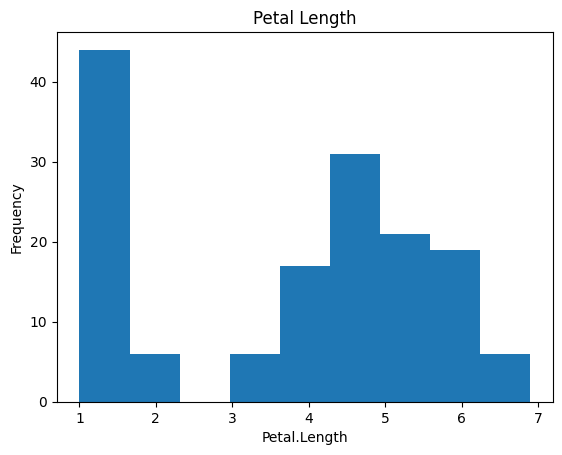

In [40]:
plt.hist(iris_df['petal.length'], bins='auto')
plt.xlabel('Petal.Length')
plt.ylabel('Frequency')
plt.title('Petal Length')
plt.show()

In [44]:
iris_df.groupby('variety').size()

variety
Setosa        50
Versicolor    50
Virginica     50
dtype: int64

In [46]:
iris_df.groupby('variety').mean(numeric_only=True)

,sepal.length,sepal.width,petal.length,petal.width,petal_length_scaled,swpal_width_z
variety,,,,,,
Setosa,5.006,3.428,1.462,0.246,0.078305,0.853263
Versicolor,5.936,2.770,4.260,1.326,0.552542,-0.661432
Virginica,6.588,2.974,5.552,2.026,0.771525,-0.191831


In [48]:
iris_df.groupby('variety')['petal.length'].agg(['mean','std','min','max'])

,mean,std,min,max
variety,,,,
Setosa,1.462,0.173664,1.0,1.9
Versicolor,4.260,0.469911,3.0,5.1
Virginica,5.552,0.551895,4.5,6.9


In [49]:
iris_df.groupby('variety')['sepal.length'].describe()

,count,mean,std,min,25%,50%,75%,max
variety,,,,,,,,
Setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
Versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
Virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


In [50]:
sc_weir_df = pd.read_csv(data_url+'sc_weir.csv')
sc_weir_df

,Chl-a,Discharge
0,51,25
1,51,25
2,53,24
3,53,24
4,54,22
...,...,...
95,122,9
96,122,9
97,124,49
98,125,9


In [51]:
sc_weir_arr = sc_weir_df.values

In [53]:
sc_weir_arr.shape

(100, 2)

In [54]:
sc_weir_arr[:,1].mean()

np.float64(14.93)

In [56]:
np.median(sc_weir_arr[:, 1])

np.float64(13.0)

In [63]:
vals,counts=np.unique(sc_weir_arr[:,1], return_counts=True)
mode_val=vals[counts.argmax()]
print(f"mode : {mode_val}")

mode : 11


In [64]:
print(vals)
print(counts)

[ 9 10 11 12 13 14 15 16 17 18 19 20 21 22 24 25 49 52]
[ 9  1 18 14 11  3  7 13  6  3  3  2  2  2  2  2  1  1]


In [66]:
qkd=sc_weir_arr[:,1]
Q1=np.percentile(qkd, 25)
Q3=np.percentile(qkd, 75)
print(f"방류량의 제 1사분위 >> {Q1}")
print(f"방류량의 제 3사분위 >> {Q3}")

방류량의 제 1사분위 >> 11.0
방류량의 제 3사분위 >> 16.0


In [67]:
cle=sc_weir_arr[:,0]
data=cle.max()-cle.min()
data

np.int64(74)

In [69]:
cle.var(ddof=0)

np.float64(506.8004000000001)

In [70]:
np.std(cle, ddof=0)

np.float64(22.51222778847087)

In [76]:
scale=(cle-cle.min())/(cle.max()-cle.min())
sc_weir_arr=np.column_stack([sc_weir_arr,scale])
sc_weir_arr

array([[5.10000000e+01, 2.50000000e+01, 0.00000000e+00],
       [5.10000000e+01, 2.50000000e+01, 0.00000000e+00],
       [5.30000000e+01, 2.40000000e+01, 2.70270270e-02],
       [5.30000000e+01, 2.40000000e+01, 2.70270270e-02],
       [5.40000000e+01, 2.20000000e+01, 4.05405405e-02],
       [5.50000000e+01, 2.20000000e+01, 5.40540541e-02],
       [5.70000000e+01, 2.10000000e+01, 8.10810811e-02],
       [5.70000000e+01, 2.10000000e+01, 8.10810811e-02],
       [5.90000000e+01, 2.00000000e+01, 1.08108108e-01],
       [6.00000000e+01, 2.00000000e+01, 1.21621622e-01],
       [6.10000000e+01, 1.90000000e+01, 1.35135135e-01],
       [6.20000000e+01, 1.90000000e+01, 1.48648649e-01],
       [6.30000000e+01, 1.90000000e+01, 1.62162162e-01],
       [6.40000000e+01, 1.80000000e+01, 1.75675676e-01],
       [6.50000000e+01, 1.80000000e+01, 1.89189189e-01],
       [6.60000000e+01, 1.80000000e+01, 2.02702703e-01],
       [6.70000000e+01, 1.70000000e+01, 2.16216216e-01],
       [6.70000000e+01, 1.70000

In [79]:
z=(qkd-qkd.mean())/np.std(qkd)
sc_weir_arr=np.column_stack([sc_weir_arr,z])
sc_weir_arr

array([[ 5.10000000e+01,  2.50000000e+01,  0.00000000e+00,
         1.58656273e+00,  1.58656273e+00],
       [ 5.10000000e+01,  2.50000000e+01,  0.00000000e+00,
         1.58656273e+00,  1.58656273e+00],
       [ 5.30000000e+01,  2.40000000e+01,  2.70270270e-02,
         1.42900933e+00,  1.42900933e+00],
       [ 5.30000000e+01,  2.40000000e+01,  2.70270270e-02,
         1.42900933e+00,  1.42900933e+00],
       [ 5.40000000e+01,  2.20000000e+01,  4.05405405e-02,
         1.11390253e+00,  1.11390253e+00],
       [ 5.50000000e+01,  2.20000000e+01,  5.40540541e-02,
         1.11390253e+00,  1.11390253e+00],
       [ 5.70000000e+01,  2.10000000e+01,  8.10810811e-02,
         9.56349132e-01,  9.56349132e-01],
       [ 5.70000000e+01,  2.10000000e+01,  8.10810811e-02,
         9.56349132e-01,  9.56349132e-01],
       [ 5.90000000e+01,  2.00000000e+01,  1.08108108e-01,
         7.98795733e-01,  7.98795733e-01],
       [ 6.00000000e+01,  2.00000000e+01,  1.21621622e-01,
         7.98795733e-01